In [7]:
import polars as pl
from hmmlearn import hmm
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [1]:
from pathlib import Path

ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
TRAIN_PATH = DATA_DIR / "processed" / "train.parquet"

### Use a HMM to infer latent regimes, then a Bayesian network to convert observed evidence into a probability of accumulation opportunity.

In [2]:
# HMM → latent market regime
# Bayesian Network → probability of accumulation opportunity
# Stacksats strategy → daily DCA multiplier

In [3]:
features = [
     "active_price",

    "realized_price",

    "mvrv",

    "mvrv_zscore",

    "market_cap",

    "supply_btc"
]

In [5]:
import polars as pl
df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("day_utc") >= pl.date(2018, 1, 1))
    .filter(pl.col("metric").is_in(features))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

In [10]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(how="all")

df.isna().mean().sort_values(ascending=False)

date              0.0
active_price      0.0
market_cap        0.0
mvrv              0.0
realized_price    0.0
supply_btc        0.0
price_usd         0.0
dtype: float64

In [11]:
df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date").sort_index()

In [12]:
ts = df.copy()
ts["mvrv_deviation"] = ts["mvrv"] - ts["mvrv"].rolling(365).mean()
ts["mvrv_z_rolling"] = (
    (ts["mvrv"] - ts["mvrv"].rolling(365).mean())
    / ts["mvrv"].rolling(365).std()
)

In [13]:
from arch import arch_model

from hmmlearn.hmm import GaussianHMM

from sklearn.preprocessing import StandardScaler

In [14]:
model_df = ts.copy()

model_df["btc_log_return"] = np.log(
    model_df["price_usd"] / model_df["price_usd"].shift(1)
)

model_df["btc_return_pct"] = model_df["btc_log_return"] * 100

model_df = model_df.replace([np.inf, -np.inf], np.nan)

In [15]:
returns = model_df["btc_return_pct"].dropna()

garch = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_result = garch.fit(disp="off")

print(garch_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:               btc_return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5576.05
Distribution:      Standardized Student's t   AIC:                           11162.1
Method:                  Maximum Likelihood   BIC:                           11190.6
                                              No. Observations:                 2190
Date:                      Tue, May 26 2026   Df Residuals:                     2189
Time:                              10:44:07   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

In [16]:
model_df.loc[returns.index, "garch_volatility"] = garch_result.conditional_volatility

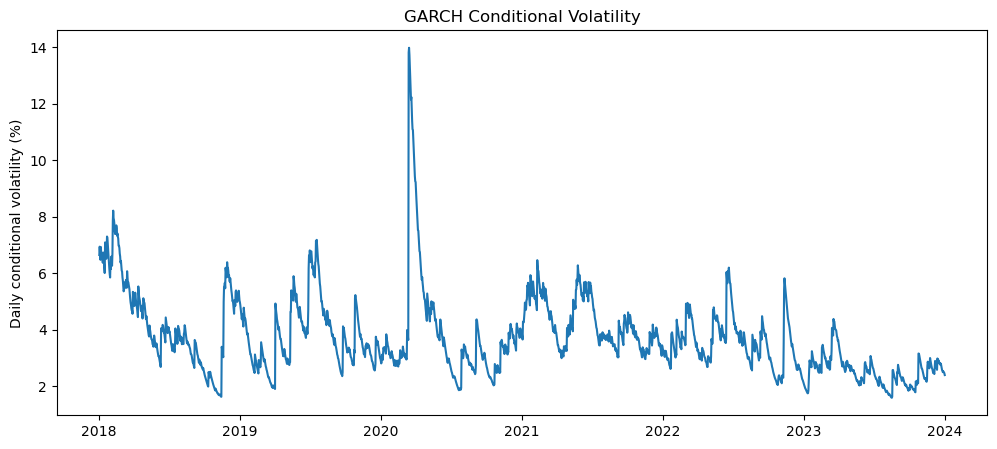

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(model_df["garch_volatility"])
plt.title("GARCH Conditional Volatility")
plt.ylabel("Daily conditional volatility (%)")
plt.show()

In [18]:
hmm_features = pd.DataFrame(index=model_df.index)

hmm_features["return"] = model_df["btc_log_return"]
hmm_features["volatility"] = model_df["garch_volatility"]
hmm_features["mvrv_z"] = model_df["mvrv_z_rolling"]
hmm_features["price_vs_active"] = (
    model_df["price_usd"] / model_df["active_price"] - 1
)

hmm_features = hmm_features.replace([np.inf, -np.inf], np.nan).dropna()

In [19]:
scaler = StandardScaler()

X = scaler.fit_transform(hmm_features)

In [20]:
hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm.fit(X)

regime_probs = hmm.predict_proba(X)

In [23]:
hmm_features["regime"] = hmm.predict(X)

In [28]:
hmm_features["price_vs_active"] = (
    model_df["price_usd"] / model_df["active_price"] - 1
)

In [29]:
for i in range(hmm.n_components):
    hmm_features[f"regime_prob_{i}"] = regime_probs[:, i]

In [33]:
prob_cols = [f"regime_prob_{i}" for i in range(hmm.n_components)]

plot_df = model_df.join(
    hmm_features[["regime","price_vs_active"] + prob_cols],
    how="left"
)

plot_df = plot_df.rename(columns={"regime": "hmm_regime"})

In [34]:
regime_summary = (
    hmm_features
    .groupby("regime")
    .mean()
)

regime_summary

,return,volatility,mvrv_z,price_vs_active,regime_prob_0,regime_prob_1,regime_prob_2
regime,,,,,,,
0,0.006480,5.216008,1.379440,2.420407,0.979914,0.002754,0.017332
1,-0.001964,3.954175,-0.617299,2.312177,0.000783,0.997434,0.001783
2,0.001105,2.880455,0.251039,1.248468,0.005578,0.000239,0.994183


In [35]:
plot_df.columns.tolist()

['active_price',
 'market_cap',
 'mvrv',
 'realized_price',
 'supply_btc',
 'price_usd',
 'mvrv_deviation',
 'mvrv_z_rolling',
 'btc_log_return',
 'btc_return_pct',
 'garch_volatility',
 'hmm_regime',
 'price_vs_active',
 'regime_prob_0',
 'regime_prob_1',
 'regime_prob_2']

In [37]:
# MVRV tells us valuation.
# GARCH volatility tells us stress.
# Price vs active price tells us participant profitability.
# HMM regime tells us latent market state.

In [36]:
bn_df = plot_df.copy()

bn_df["valuation_state"] = pd.cut(
    bn_df["mvrv_z_rolling"],
    bins=[-np.inf, -1.0, 1.0, np.inf],
    labels=["cheap", "neutral", "expensive"]
)

bn_df["volatility_state"] = pd.cut(
    bn_df["garch_volatility"].rank(pct=True),
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["low", "medium", "high"]
)

bn_df["active_price_state"] = pd.cut(
    bn_df["price_vs_active"],
    bins=[-np.inf, -0.05, 0.10, np.inf],
    labels=["below_active", "near_active", "above_active"]
)

bn_df["regime_state"] = bn_df["hmm_regime"].astype(str)

In [39]:
# Accumulation target
# Cheap valuation + stress = accumulation opportunity
bn_df["accumulation_opportunity"] = np.where(
    (
        (bn_df["valuation_state"] == "cheap")
        & (
            (bn_df["volatility_state"] == "high")
            | (bn_df["active_price_state"] == "below_active")
        )
    ),
    "yes",
    "no"
)

In [40]:
bn_train = bn_df[
    [
        "regime_state",
        "valuation_state",
        "volatility_state",
        "active_price_state",
        "accumulation_opportunity",
    ]
].dropna()

bn_train = bn_train.astype(str)

In [43]:
from pgmpy.models import BayesianNetwork, DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

In [44]:
# Accumulation opportunity depends on:
# - latent HMM regime
# - valuation
# - volatility
# - active price state
model = DiscreteBayesianNetwork([
    ("regime_state", "accumulation_opportunity"),
    ("valuation_state", "accumulation_opportunity"),
    ("volatility_state", "accumulation_opportunity"),
    ("active_price_state", "accumulation_opportunity"),
])

In [52]:
model.fit(bn_train)

model.check_model()

infer = VariableElimination(model)

In [54]:
def get_accumulation_probability(row):
    evidence = {
        "regime_state": str(row["regime_state"]),
        "valuation_state": str(row["valuation_state"]),
        "volatility_state": str(row["volatility_state"]),
        "active_price_state": str(row["active_price_state"]),
    }

    try:
        result = infer.query(
            variables=["accumulation_opportunity"],
            evidence=evidence,
            show_progress=False,
        )

        states = result.state_names["accumulation_opportunity"]
        values = result.values

        prob_yes = dict(zip(states, values)).get("yes", 0.0)

        return float(prob_yes)

    except Exception:
        return 0.0

In [55]:
bn_df["bayes_accumulation_prob"] = bn_df.apply(
    get_accumulation_probability,
    axis=1
)

In [56]:
# P(accumulation) = 0.0 → 1.0x DCA
# P(accumulation) = 0.5 → 1.75x DCA
# P(accumulation) = 1.0 → 2.5x DCA

In [57]:
bn_df["hmm_bayes_allocation_weight"] = (
    1.0 + 1.5 * bn_df["bayes_accumulation_prob"]
).clip(0.50, 2.50)

In [58]:
bn_df["hmm_bayes_allocation_weight"] = (
    bn_df["hmm_bayes_allocation_weight"]
    .rolling(7)
    .mean()
    .fillna(bn_df["hmm_bayes_allocation_weight"])
)

In [59]:
signals_pd = (
    bn_df
    .reset_index()
    [["date", "hmm_bayes_allocation_weight", "bayes_accumulation_prob"]]
)

btc_df_bayes = (
    df.reset_index()
    .merge(signals_pd, on="date", how="left")
)

btc_df_bayes["hmm_bayes_allocation_weight"] = (
    btc_df_bayes["hmm_bayes_allocation_weight"]
    .fillna(1.0)
)

In [60]:
btc_df_bayes_pl = pl.from_pandas(btc_df_bayes).with_columns(
    pl.col("date").cast(pl.Date)
)

In [62]:
from stacksats import BaseStrategy

class HMMBayesAccumulationStrategy(BaseStrategy):
    strategy_id = "hmm-bayes-accumulation"
    version = "1.0.0"

    def __init__(self, signal_df, min_weight=0.50, max_weight=2.50):
        self.min_weight = min_weight
        self.max_weight = max_weight

        self.signal_df = (
            signal_df
            .select(["date", "hmm_bayes_allocation_weight"])
            .with_columns(pl.col("date").cast(pl.Date))
        )

    def params(self):
        return {
            "min_weight": self.min_weight,
            "max_weight": self.max_weight,
            "signal_column": "hmm_bayes_allocation_weight",
        }

    def propose_weight(self, state):
        current_date = (
            state.features
            .select("date")
            .tail(1)
            .item()
        )

        signal_row = self.signal_df.filter(
            pl.col("date") == current_date
        )

        if signal_row.is_empty():
            signal = 1.0
        else:
            signal = (
                signal_row
                .select("hmm_bayes_allocation_weight")
                .item()
            )

        if signal is None:
            signal = 1.0

        signal = float(signal)
        signal = max(self.min_weight, min(signal, self.max_weight))

        return state.uniform_weight * signal

In [68]:
start_date = "2018-01-01"
end_date = "2024-01-01"

In [69]:
from stacksats import StrategyRunner, BacktestConfig, ExportConfig

hmm_bayes = HMMBayesAccumulationStrategy(signal_df=btc_df_bayes_pl)

runner = StrategyRunner()

hmm_bayes_bt = runner.backtest(
    hmm_bayes,
    config=BacktestConfig(
        start_date=start_date,
        end_date=end_date,
    ),
    btc_df=btc_df_bayes_pl,
)

In [70]:
hmm_bayes_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2018-01-01 → 2018-12-31""",5842.827929,31422.726801,14736.064632,14736.064632,34.766505,34.766505,2.2027e-13
"""2018-01-02 → 2019-01-01""",5842.827929,31422.726801,14787.64918,14788.167381,34.968165,34.970191,0.002026
"""2018-01-03 → 2019-01-02""",5842.827929,31422.726801,14839.550357,14841.114038,35.171063,35.177176,0.006113
"""2018-01-04 → 2019-01-03""",5842.827929,31422.726801,14893.784195,14893.278786,35.383081,35.381105,-0.001976
"""2018-01-05 → 2019-01-04""",5842.827929,31422.726801,14947.312798,14946.965065,35.592341,35.590982,-0.001359
…,…,…,…,…,…,…,…
"""2022-12-28 → 2023-12-27""",2263.929335,6055.677106,3645.624389,3645.624389,36.43953,36.43953,-3.5527e-14
"""2022-12-29 → 2023-12-28""",2263.929335,6055.677106,3635.497492,3635.497492,36.172452,36.172452,-1.4211e-14
"""2022-12-30 → 2023-12-29""",2263.929335,6055.677106,3625.550662,3625.550662,35.910124,35.910124,-3.5527e-14


In [71]:
hmm_bayes_bt.summary()

'Score: 54.07% | Win Rate: 70.77% | Exp-Decay Percentile: 37.38% | Uniform Exp-Decay: 37.29% | Exp-Decay Multiple: 1.002x | Windows: 1827'

In [74]:
from stacksats import UniformStrategy, ComparisonConfig

uniform_strategy = UniformStrategy()

result = runner.compare(
    strategies=[
        hmm_bayes,
        uniform_strategy
    ],
    config=ComparisonConfig(
        start_date=start_date,
        end_date=end_date,
        baseline="uniform",
        strict=False,
        output_dir="output",
    ),
    btc_df=btc_df_bayes_pl,
)

result

ComparisonResult(baseline_selector='uniform', comparison_window={'start_date': '2018-01-01', 'end_date': '2024-01-01', 'strict': False, 'min_win_rate': 50.0}, rows=[ComparisonRow(selector='hmm-bayes-accumulation', strategy_id='hmm-bayes-accumulation', strategy_version='1.0.0', intent_mode='propose', tier=None, promotion_stage=None, validation_passed=True, judgment_label='validation-passed', win_rate=70.77175697865353, score=54.07349145106356, exp_decay_percentile=37.375225923473586, multiple_vs_uniform=1.0022415457634033, score_delta_vs_baseline=35.42767394256815, exp_decay_delta_vs_baseline=0.08359090648275469, is_baseline=False), ComparisonRow(selector='uniform', strategy_id='uniform', strategy_version='1.0.0', intent_mode='propose', tier='stable', promotion_stage='promoted', validation_passed=False, judgment_label='validation-failed', win_rate=0.0, score=18.645817508495416, exp_decay_percentile=37.29163501699083, multiple_vs_uniform=0.999999999999999, score_delta_vs_baseline=0.0, ex

The HMM estimates hidden market regimes.
The Bayesian network takes the regime plus observed evidence and estimates the probability that today is an accumulation opportunity.
The strategy converts that probability into a DCA multiplier.

In [76]:
calendar_cycles = [
    {
        "label": "Cycle 1: 2010-2013",
        "start": "2010-08-16",
        "end": "2013-12-31"
    },
    {
        "label": "Cycle 2: 2014-2017",
        "start": "2014-01-01",
        "end": "2017-12-31"
    },
    {
        "label": "Cycle 3: 2018-2021",
        "start": "2018-01-01",
        "end": "2021-12-31"
    },
    {
        "label": "Cycle 4: 2022-2023",
        "start": "2022-01-01",
        "end": "2023-12-31"
    }
]

# Actual halving periods used only for background shading.
halving_periods = [
    {
        "label": "Before Nov 2012 Halving",
        "start": "2010-08-16",
        "end": "2012-11-27",
        "color": "rgba(173, 216, 230, 0.25)"
    },
    {
        "label": "2012-2016 Halving Cycle",
        "start": "2012-11-28",
        "end": "2016-07-08",
        "color": "rgba(144, 238, 144, 0.25)"
    },
    {
        "label": "2016-2020 Halving Cycle",
        "start": "2016-07-09",
        "end": "2020-05-10",
        "color": "rgba(176, 196, 222, 0.25)"
    },
    {
        "label": "2020-2024 Halving Cycle",
        "start": "2020-05-11",
        "end": "2023-12-31",
        "color": "rgba(238, 232, 170, 0.25)"
    }
]

In [77]:
def export_one_year(
    strategy,
    btc_data: pl.DataFrame,
    year: int,
    runner: StrategyRunner
) -> pl.DataFrame | None:
    
    year_start = f"{year}-01-01"
    year_end = f"{year}-12-31"

    year_df = (
        btc_data
        .filter(
            (pl.col("date") >= pl.datetime(year, 1, 1)) &
            (pl.col("date") <= pl.datetime(year, 12, 31))
        )
        .sort("date")
    )

    if year_df.is_empty():
        print(f"{year}: skipped, no data")
        return None

    if year_df.height < 365:
        print(f"{year}: skipped, less than 365 rows")
        return None

    try:
        config = ExportConfig(
            range_start=year_start,
            range_end=year_end
        )

        export_obj = runner.export(strategy, config, btc_df=year_df)
        df = export_obj.to_dataframe()

        df = df.with_columns([
            pl.col("start_date").cast(pl.Datetime),
            pl.col("end_date").cast(pl.Datetime),
            pl.col("date").cast(pl.Datetime),
        ])

        # For leap years, export can produce two 365-day windows.
        # Keep the one ending latest.
        latest_end = df.select(pl.col("end_date").max()).item()

        df_one = (
            df
            .filter(pl.col("end_date") == latest_end)
            .sort("date")
        )

        print(f"{year}: exported {df_one.height} rows")
        return df_one

    except Exception as e:
        print(f"{year}: skipped due to error -> {e}")
        return None

In [78]:
hmm_yearly = []
uniform_yearly = []
uniform_strategy = UniformStrategy()

for year in range(2018, 2024):
    hmm = export_one_year(hmm_bayes, btc_df_bayes_pl, year, runner)
    if hmm is not None:
        hmm_yearly.append(hmm)

    uniform_result = export_one_year(uniform_strategy, btc_df_bayes_pl, year, runner)
    if uniform_result is not None:
        uniform_yearly.append(uniform_result)

print("HMM valid yearly exports:", len(hmm_yearly))
print("Uniform valid yearly exports:", len(uniform_yearly))
if not hmm_yearly:
    raise ValueError("No valid HMM exports were produced.")

if not uniform_yearly:
    raise ValueError("No valid Uniform exports were produced.")

hmm_all = pl.concat(hmm_yearly).rename({"weight": "hmm_weight_raw"})
uniform_all = pl.concat(uniform_yearly).rename({"weight": "baseline_weight_raw"})

print("HMM combined rows:", hmm_all.height)
print("Uniform combined rows:", uniform_all.height)
merged = (
    hmm_all
    .select(["date", "price_usd", "hmm_weight_raw"])
    .join(
        uniform_all.select(["date", "baseline_weight_raw"]),
        on="date",
        how="inner"
    )
    .sort("date")
)

print("Merged rows:", merged.height)

merged.head()
hmm_sum = merged["hmm_weight_raw"].sum()
uniform_sum = merged["baseline_weight_raw"].sum()

merged = merged.with_columns([
    (pl.col("hmm_weight_raw") / hmm_sum).alias("hmm_weight"),
    (pl.col("baseline_weight_raw") / uniform_sum).alias("baseline_weight"),
])

print("HMM normalized weight sum:", merged["hmm_weight"].sum())
print("Uniform normalized weight sum:", merged["baseline_weight"].sum())
total_budget_usd = 1000.0

merged = merged.with_columns([
    (pl.col("hmm_weight") * total_budget_usd).alias("hmm_usd"),
    (pl.col("baseline_weight") * total_budget_usd).alias("baseline_usd"),
])

merged = merged.with_columns([
    (pl.col("hmm_usd") / pl.col("price_usd")).alias("btc_accum_hmm"),
    (pl.col("baseline_usd") / pl.col("price_usd")).alias("btc_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("btc_accum_hmm") * 100_000_000).alias("sats_accum_hmm"),
    (pl.col("btc_accum_baseline") * 100_000_000).alias("sats_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("sats_accum_hmm") / pl.col("hmm_usd")).alias("sats_per_dollar_hmm"),
    (pl.col("sats_accum_baseline") / pl.col("baseline_usd")).alias("sats_per_dollar_baseline"),
])

total_dynamic_btc = merged["btc_accum_hmm"].sum()
total_baseline_btc = merged["btc_accum_baseline"].sum()

sats_per_dollar_dynamic = (total_dynamic_btc / total_budget_usd) * 100_000_000
sats_per_dollar_baseline = (total_baseline_btc / total_budget_usd) * 100_000_000

pct_diff_vs_baseline = (
    (total_dynamic_btc - total_baseline_btc) / total_baseline_btc
) * 100

performance_label = "better" if pct_diff_vs_baseline > 0 else "worse"

print(f"Total BTC accumulated, hmm: {total_dynamic_btc:.6f}")
print(f"Total BTC accumulated, Uniform: {total_baseline_btc:.6f}")
print(f"Sats per dollar, hmm: {sats_per_dollar_dynamic:.2f}")
print(f"Sats per dollar, Uniform: {sats_per_dollar_baseline:.2f}")
print(f"hmm performed {abs(pct_diff_vs_baseline):.2f}% {performance_label} than Uniform")
def assign_cycle_label(date):
    for cycle in calendar_cycles:
        start = pd.to_datetime(cycle["start"])
        end = pd.to_datetime(cycle["end"])
        if start <= date <= end:
            return cycle["label"]
    return "Outside cycle"


plot_df = merged.to_pandas()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["year"] = plot_df["date"].dt.year
plot_df["cycle_label"] = plot_df["date"].apply(assign_cycle_label)

plot_df.head()
top_buy_points_list = []

for year, year_df in plot_df.groupby("year"):
    threshold = year_df["hmm_weight"].quantile(0.90)

    top_year_df = year_df[year_df["hmm_weight"] >= threshold].copy()
    top_year_df["top_buy_threshold_year"] = threshold

    top_buy_points_list.append(top_year_df)

top_buy_points = pd.concat(top_buy_points_list, ignore_index=True)

top_buy_points = top_buy_points.sort_values(
    ["year", "hmm_weight"],
    ascending=[True, False]
)

print("Top buy points:", len(top_buy_points))
top_buy_points[["date", "year", "price_usd", "hmm_weight", "top_buy_threshold_year"]].head()
import plotly.graph_objects as go

fig = go.Figure()

# Add actual halving-period background shading.
for period in halving_periods:
    fig.add_vrect(
        x0=pd.to_datetime(period["start"]),
        x1=pd.to_datetime(period["end"]),
        fillcolor=period["color"],
        opacity=1.0,
        layer="below",
        line_width=0,
        annotation_text=period["label"],
        annotation_position="top left",
        annotation_font_size=11,
    )

# Add vertical dotted lines for calendar cycle starts.
for cycle in calendar_cycles:
    fig.add_vline(
        x=pd.to_datetime(cycle["start"]),
        line_width=1,
        line_dash="dot",
        line_color="gray"
    )

# BTC price line on left y-axis.
fig.add_trace(
    go.Scatter(
        x=plot_df["date"],
        y=plot_df["price_usd"],
        mode="lines",
        name="BTC Price (USD)",
        line=dict(color="black", width=2),
        yaxis="y1",
        customdata=plot_df[
            [
                "year",
                "cycle_label",
                "hmm_weight",
                "baseline_weight",
                "sats_per_dollar_hmm",
                "sats_per_dollar_baseline",
                "sats_accum_hmm",
                "sats_accum_baseline",
            ]
        ],
        hovertemplate=(
            "<b>Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Year</b>: %{customdata[0]}<br>"
            "<b>Cycle</b>: %{customdata[1]}<br>"
            "<b>BTC Price</b>: $%{y:,.2f}<br>"
            "<b>hmm Weight</b>: %{customdata[2]:.8f}<br>"
            "<b>DCA Weight</b>: %{customdata[3]:.8f}<br>"
            "<b>hmm sats/$</b>: %{customdata[4]:,.2f}<br>"
            "<b>DCA sats/$</b>: %{customdata[5]:,.2f}<br>"
            "<b>hmm sats accumulated</b>: %{customdata[6]:,.2f}<br>"
            "<b>DCA sats accumulated</b>: %{customdata[7]:,.2f}"
            "<extra></extra>"
        )
    )
)

# Momentum allocation weight on right y-axis.
fig.add_trace(
    go.Scatter(
        x=plot_df["date"],
        y=plot_df["hmm_weight"],
        mode="lines",
        name="hmm Weight",
        line=dict(color="green", width=1.5),
        fill="tozeroy",
        fillcolor="rgba(0, 128, 0, 0.35)",
        yaxis="y2",
        customdata=plot_df[
            [
                "year",
                "cycle_label",
                "price_usd",
                "sats_per_dollar_hmm",
                "sats_accum_hmm",
            ]
        ],
        hovertemplate=(
            "<b>Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Year</b>: %{customdata[0]}<br>"
            "<b>Cycle</b>: %{customdata[1]}<br>"
            "<b>hmm Weight</b>: %{y:.8f}<br>"
            "<b>BTC Price</b>: $%{customdata[2]:,.2f}<br>"
            "<b>hmm sats/$</b>: %{customdata[3]:,.2f}<br>"
            "<b>hmm sats accumulated</b>: %{customdata[4]:,.2f}"
            "<extra></extra>"
        )
    )
)

# Baseline DCA allocation weight on right y-axis.
fig.add_trace(
    go.Scatter(
        x=plot_df["date"],
        y=plot_df["baseline_weight"],
        mode="lines",
        name="Baseline DCA Weight",
        line=dict(color="orange", width=2, dash="dash"),
        yaxis="y2",
        customdata=plot_df[
            [
                "year",
                "cycle_label",
                "price_usd",
                "sats_per_dollar_baseline",
                "sats_accum_baseline",
            ]
        ],
        hovertemplate=(
            "<b>Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Year</b>: %{customdata[0]}<br>"
            "<b>Cycle</b>: %{customdata[1]}<br>"
            "<b>DCA Weight</b>: %{y:.8f}<br>"
            "<b>BTC Price</b>: $%{customdata[2]:,.2f}<br>"
            "<b>DCA sats/$</b>: %{customdata[3]:,.2f}<br>"
            "<b>DCA sats accumulated</b>: %{customdata[4]:,.2f}"
            "<extra></extra>"
        )
    )
)

# Top 10% buy points calculated yearly.
fig.add_trace(
    go.Scatter(
        x=top_buy_points["date"],
        y=top_buy_points["price_usd"],
        mode="markers",
        name="Top 10% Buy Days, Yearly",
        marker=dict(
            color="green",
            symbol="triangle-up",
            size=8,
            line=dict(color="black", width=0.8)
        ),
        yaxis="y1",
        customdata=top_buy_points[
            [
                "year",
                "cycle_label",
                "hmm_weight",
                "top_buy_threshold_year",
            ]
        ],
        hovertemplate=(
            "<b>Top 10% Buy Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Year</b>: %{customdata[0]}<br>"
            "<b>Cycle</b>: %{customdata[1]}<br>"
            "<b>BTC Price</b>: $%{y:,.2f}<br>"
            "<b>hmm Weight</b>: %{customdata[2]:.8f}<br>"
            "<b>Yearly Top 10% Threshold</b>: %{customdata[3]:.8f}"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title=(
        "hmm Strategy vs Baseline DCA, 2018-2023<br>"
        "Top Buy Markers = Top 10% hmm Weights Within Each Year<br>"
        f"hmm BTC: {total_dynamic_btc:.6f} | "
        f"DCA BTC: {total_baseline_btc:.6f} | "
        f"hmm performed {abs(pct_diff_vs_baseline):.2f}% {performance_label} than DCA"
    ),
    width=1450,
    height=780,
    hovermode="x unified",
    xaxis=dict(
        title="Date",
        range=[
            pd.to_datetime("2018-01-01"),
            pd.to_datetime("2023-12-31")
        ],
    ),
    yaxis=dict(
        title="BTC Price (USD, log scale)",
        type="log",
        side="left",
    ),
    yaxis2=dict(
        title="Allocation Weight",
        overlaying="y",
        side="right",
        showgrid=False,
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0,
    ),
    margin=dict(l=70, r=70, t=150, b=60),
)

fig.show()

2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows
2022: exported 365 rows
2022: exported 365 rows
2023: exported 365 rows
2023: exported 365 rows
HMM valid yearly exports: 6
Uniform valid yearly exports: 6
HMM combined rows: 2190
Uniform combined rows: 2190
Merged rows: 2190
HMM normalized weight sum: 1.0
Uniform normalized weight sum: 1.0000000000000002
Total BTC accumulated, hmm: 0.087562
Total BTC accumulated, Uniform: 0.084188
Sats per dollar, hmm: 8756.17
Sats per dollar, Uniform: 8418.79
hmm performed 4.01% better than Uniform
Top buy points: 1188


## V2

In [79]:
# If buying today was followed by relatively strong future appreciation,
# label today as an accumulation opportunity.

In [82]:
plot_df.columns.tolist()

['date',
 'price_usd',
 'hmm_weight_raw',
 'baseline_weight_raw',
 'hmm_weight',
 'baseline_weight',
 'hmm_usd',
 'baseline_usd',
 'btc_accum_hmm',
 'btc_accum_baseline',
 'sats_accum_hmm',
 'sats_accum_baseline',
 'sats_per_dollar_hmm',
 'sats_per_dollar_baseline',
 'year',
 'cycle_label']

In [86]:
import polars as pl
df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("day_utc") >= pl.date(2018, 1, 1))
    .filter(pl.col("metric").is_in(features))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

df = df.to_pandas()

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(how="all")

df.isna().mean().sort_values(ascending=False)
df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date").sort_index()
ts = df.copy()
ts["mvrv_deviation"] = ts["mvrv"] - ts["mvrv"].rolling(365).mean()
ts["mvrv_z_rolling"] = (
    (ts["mvrv"] - ts["mvrv"].rolling(365).mean())
    / ts["mvrv"].rolling(365).std()
)
model_df = ts.copy()

model_df["btc_log_return"] = np.log(
    model_df["price_usd"] / model_df["price_usd"].shift(1)
)

model_df["btc_return_pct"] = model_df["btc_log_return"] * 100

model_df = model_df.replace([np.inf, -np.inf], np.nan)
returns = model_df["btc_return_pct"].dropna()

garch = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_result = garch.fit(disp="off")

print(garch_result.summary())
model_df.loc[returns.index, "garch_volatility"] = garch_result.conditional_volatility
hmm_features = pd.DataFrame(index=model_df.index)

hmm_features["return"] = model_df["btc_log_return"]
hmm_features["volatility"] = model_df["garch_volatility"]
hmm_features["mvrv_z"] = model_df["mvrv_z_rolling"]
hmm_features["price_vs_active"] = (
    model_df["price_usd"] / model_df["active_price"] - 1
)

hmm_features = hmm_features.replace([np.inf, -np.inf], np.nan).dropna()
scaler = StandardScaler()

X = scaler.fit_transform(hmm_features)
hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm.fit(X)

regime_probs = hmm.predict_proba(X)
hmm_features["regime"] = hmm.predict(X)
hmm_features["price_vs_active"] = (
    model_df["price_usd"] / model_df["active_price"] - 1
)
for i in range(hmm.n_components):
    hmm_features[f"regime_prob_{i}"] = regime_probs[:, i]
prob_cols = [f"regime_prob_{i}" for i in range(hmm.n_components)]

plot_df = model_df.join(
    hmm_features[["regime","price_vs_active"] + prob_cols],
    how="left"
)

plot_df = plot_df.rename(columns={"regime": "hmm_regime"})

                        Constant Mean - GARCH Model Results                         
Dep. Variable:               btc_return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5576.05
Distribution:      Standardized Student's t   AIC:                           11162.1
Method:                  Maximum Likelihood   BIC:                           11190.6
                                              No. Observations:                 2190
Date:                      Tue, May 26 2026   Df Residuals:                     2189
Time:                              11:23:45   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

In [87]:
label_horizon = 90

bn_df = plot_df.copy()

bn_df["future_price"] = bn_df["price_usd"].shift(-label_horizon)

bn_df["forward_return"] = (
    bn_df["future_price"] / bn_df["price_usd"] - 1
)

bn_df["future_sats_per_dollar"] = 1 / bn_df["price_usd"]

threshold = bn_df["forward_return"].quantile(0.65)

bn_df["accumulation_opportunity"] = np.where(
    bn_df["forward_return"] >= threshold,
    "yes",
    "no"
)

In [88]:
bn_df["valuation_state"] = pd.cut(
    bn_df["mvrv_z_rolling"],
    bins=[-np.inf, -1.0, 1.0, np.inf],
    labels=["cheap", "neutral", "expensive"]
)

bn_df["volatility_state"] = pd.cut(
    bn_df["garch_volatility"].rank(pct=True),
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["low", "medium", "high"]
)

bn_df["active_price_state"] = pd.cut(
    bn_df["price_vs_active"],
    bins=[-np.inf, -0.05, 0.10, np.inf],
    labels=["below_active", "near_active", "above_active"]
)

bn_df["trend_state"] = np.where(
    bn_df["price_usd"] > bn_df["price_usd"].rolling(200).mean(),
    "uptrend",
    "downtrend"
)

In [89]:
for i in range(hmm.n_components):
    col = f"regime_prob_{i}"
    bn_df[f"{col}_state"] = pd.cut(
        bn_df[col],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["low", "medium", "high"]
    )

In [90]:
prob_state_cols = [
    f"regime_prob_{i}_state"
    for i in range(hmm.n_components)
]

bn_cols = [
    "valuation_state",
    "volatility_state",
    "active_price_state",
    "trend_state",
    *prob_state_cols,
    "accumulation_opportunity",
]

bn_train = bn_df[bn_cols].dropna().astype(str)

In [91]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination

edges = [
    ("valuation_state", "accumulation_opportunity"),
    ("volatility_state", "accumulation_opportunity"),
    ("active_price_state", "accumulation_opportunity"),
    ("trend_state", "accumulation_opportunity"),
]

for col in prob_state_cols:
    edges.append((col, "accumulation_opportunity"))

bayes_model = DiscreteBayesianNetwork(edges)

bayes_model.fit(bn_train)
bayes_model.check_model()

infer = VariableElimination(bayes_model)

In [93]:
def get_accumulation_probability(row):
    evidence = {
        col: str(row[col])
        for col in bn_cols
        if col != "accumulation_opportunity"
    }

    try:
        result = infer.query(
            variables=["accumulation_opportunity"],
            evidence=evidence,
            show_progress=False,
        )

        states = result.state_names["accumulation_opportunity"]
        values = result.values

        return float(dict(zip(states, values)).get("yes", 0.0))

    except Exception:
        return 0.0

In [94]:
bn_df["bayes_accumulation_prob"] = bn_df.apply(
    get_accumulation_probability,
    axis=1
)

In [95]:
bn_df["accumulation_boost"] = (
    1.0 + 1.8 * (bn_df["bayes_accumulation_prob"] ** 2)
)

In [97]:
euphoric_regime = 0
accumulation_regime = 1
neutral_regime = 2

In [98]:
euphoric_prob_col = f"regime_prob_{euphoric_regime}"

bn_df["euphoria_penalty"] = (
    1 - 0.20 * bn_df[euphoric_prob_col]
).clip(0.80, 1.0)

In [99]:
bn_df["hmm_bayes_v2_allocation_weight"] = (
    bn_df["accumulation_boost"]
    * bn_df["euphoria_penalty"]
).clip(0.50, 2.50)

In [100]:
bn_df["hmm_bayes_v2_allocation_weight"] = (
    bn_df["hmm_bayes_v2_allocation_weight"]
    .rolling(7)
    .mean()
    .fillna(bn_df["hmm_bayes_v2_allocation_weight"])
)

In [101]:
signals_pd = (
    bn_df
    .reset_index()
    [["date", "hmm_bayes_v2_allocation_weight", "bayes_accumulation_prob"]]
)

btc_df_bayes_v2 = (
    df.reset_index()
    .merge(signals_pd, on="date", how="left")
)

btc_df_bayes_v2["hmm_bayes_v2_allocation_weight"] = (
    btc_df_bayes_v2["hmm_bayes_v2_allocation_weight"]
    .fillna(1.0)
)

In [102]:
btc_df_bayes_v2_pl = pl.from_pandas(btc_df_bayes_v2).with_columns(
    pl.col("date").cast(pl.Date)
)

In [103]:
class HMMBayesV2Strategy(BaseStrategy):
    strategy_id = "hmm-bayes-v2"
    version = "1.0.0"

    def __init__(self, signal_df, min_weight=0.50, max_weight=2.50):
        self.min_weight = min_weight
        self.max_weight = max_weight

        self.signal_df = (
            signal_df
            .select(["date", "hmm_bayes_v2_allocation_weight"])
            .with_columns(pl.col("date").cast(pl.Date))
        )

    def params(self):
        return {
            "min_weight": self.min_weight,
            "max_weight": self.max_weight,
            "signal_column": "hmm_bayes_v2_allocation_weight",
        }

    def propose_weight(self, state):
        current_date = (
            state.features
            .select("date")
            .tail(1)
            .item()
        )

        signal_row = self.signal_df.filter(
            pl.col("date") == current_date
        )

        if signal_row.is_empty():
            signal = 1.0
        else:
            signal = (
                signal_row
                .select("hmm_bayes_v2_allocation_weight")
                .item()
            )

        if signal is None:
            signal = 1.0

        signal = float(signal)
        signal = max(self.min_weight, min(signal, self.max_weight))

        return state.uniform_weight * signal

In [104]:
hmm_bayes_v2 = HMMBayesV2Strategy(signal_df=btc_df_bayes_v2_pl)

hmm_bayes_v2_bt = runner.backtest(
    hmm_bayes_v2,
    config=BacktestConfig(
        start_date=start_date,
        end_date=end_date,
    ),
    btc_df=btc_df_bayes_v2_pl,
)

In [106]:
hmm_bayes_v2_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2018-01-01 → 2018-12-31""",5842.827929,31422.726801,14736.064632,14736.064632,34.766505,34.766505,2.2027e-13
"""2018-01-02 → 2019-01-01""",5842.827929,31422.726801,14787.64918,14790.058625,34.968165,34.977584,0.009419
"""2018-01-03 → 2019-01-02""",5842.827929,31422.726801,14839.550357,14843.860001,35.171063,35.187911,0.016848
"""2018-01-04 → 2019-01-03""",5842.827929,31422.726801,14893.784195,14897.645116,35.383081,35.398174,0.015094
"""2018-01-05 → 2019-01-04""",5842.827929,31422.726801,14947.312798,14950.254323,35.592341,35.60384,0.011499
…,…,…,…,…,…,…,…
"""2022-12-28 → 2023-12-27""",2263.929335,6055.677106,3645.624389,3971.690862,36.43953,45.038901,8.599371
"""2022-12-29 → 2023-12-28""",2263.929335,6055.677106,3635.497492,3960.974754,36.172452,44.756284,8.583832
"""2022-12-30 → 2023-12-29""",2263.929335,6055.677106,3625.550662,3950.186492,35.910124,44.471765,8.561641


In [107]:
hmm_bayes_v2_bt.summary()

'Score: 61.47% | Win Rate: 77.07% | Exp-Decay Percentile: 45.87% | Uniform Exp-Decay: 37.29% | Exp-Decay Multiple: 1.230x | Windows: 1827'

In [108]:
hmm_yearly = []
uniform_yearly = []
uniform_strategy = UniformStrategy()

for year in range(2018, 2024):
    hmm = export_one_year(hmm_bayes_v2, btc_df_bayes_v2_pl, year, runner)
    if hmm is not None:
        hmm_yearly.append(hmm)

    uniform_result = export_one_year(uniform_strategy, btc_df_bayes_v2_pl, year, runner)
    if uniform_result is not None:
        uniform_yearly.append(uniform_result)

print("HMM valid yearly exports:", len(hmm_yearly))
print("Uniform valid yearly exports:", len(uniform_yearly))
if not hmm_yearly:
    raise ValueError("No valid HMM exports were produced.")

if not uniform_yearly:
    raise ValueError("No valid Uniform exports were produced.")

hmm_all = pl.concat(hmm_yearly).rename({"weight": "hmm_weight_raw"})
uniform_all = pl.concat(uniform_yearly).rename({"weight": "baseline_weight_raw"})

print("HMM combined rows:", hmm_all.height)
print("Uniform combined rows:", uniform_all.height)
merged = (
    hmm_all
    .select(["date", "price_usd", "hmm_weight_raw"])
    .join(
        uniform_all.select(["date", "baseline_weight_raw"]),
        on="date",
        how="inner"
    )
    .sort("date")
)

print("Merged rows:", merged.height)

merged.head()
hmm_sum = merged["hmm_weight_raw"].sum()
uniform_sum = merged["baseline_weight_raw"].sum()

merged = merged.with_columns([
    (pl.col("hmm_weight_raw") / hmm_sum).alias("hmm_weight"),
    (pl.col("baseline_weight_raw") / uniform_sum).alias("baseline_weight"),
])

print("HMM normalized weight sum:", merged["hmm_weight"].sum())
print("Uniform normalized weight sum:", merged["baseline_weight"].sum())
total_budget_usd = 1000.0

merged = merged.with_columns([
    (pl.col("hmm_weight") * total_budget_usd).alias("hmm_usd"),
    (pl.col("baseline_weight") * total_budget_usd).alias("baseline_usd"),
])

merged = merged.with_columns([
    (pl.col("hmm_usd") / pl.col("price_usd")).alias("btc_accum_hmm"),
    (pl.col("baseline_usd") / pl.col("price_usd")).alias("btc_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("btc_accum_hmm") * 100_000_000).alias("sats_accum_hmm"),
    (pl.col("btc_accum_baseline") * 100_000_000).alias("sats_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("sats_accum_hmm") / pl.col("hmm_usd")).alias("sats_per_dollar_hmm"),
    (pl.col("sats_accum_baseline") / pl.col("baseline_usd")).alias("sats_per_dollar_baseline"),
])

total_dynamic_btc = merged["btc_accum_hmm"].sum()
total_baseline_btc = merged["btc_accum_baseline"].sum()

sats_per_dollar_dynamic = (total_dynamic_btc / total_budget_usd) * 100_000_000
sats_per_dollar_baseline = (total_baseline_btc / total_budget_usd) * 100_000_000

pct_diff_vs_baseline = (
    (total_dynamic_btc - total_baseline_btc) / total_baseline_btc
) * 100

performance_label = "better" if pct_diff_vs_baseline > 0 else "worse"

print(f"Total BTC accumulated, hmm: {total_dynamic_btc:.6f}")
print(f"Total BTC accumulated, Uniform: {total_baseline_btc:.6f}")
print(f"Sats per dollar, hmm: {sats_per_dollar_dynamic:.2f}")
print(f"Sats per dollar, Uniform: {sats_per_dollar_baseline:.2f}")
print(f"hmm performed {abs(pct_diff_vs_baseline):.2f}% {performance_label} than Uniform")
def assign_cycle_label(date):
    for cycle in calendar_cycles:
        start = pd.to_datetime(cycle["start"])
        end = pd.to_datetime(cycle["end"])
        if start <= date <= end:
            return cycle["label"]
    return "Outside cycle"


plot_df = merged.to_pandas()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["year"] = plot_df["date"].dt.year
plot_df["cycle_label"] = plot_df["date"].apply(assign_cycle_label)

plot_df.head()
top_buy_points_list = []

for year, year_df in plot_df.groupby("year"):
    threshold = year_df["hmm_weight"].quantile(0.90)

    top_year_df = year_df[year_df["hmm_weight"] >= threshold].copy()
    top_year_df["top_buy_threshold_year"] = threshold

    top_buy_points_list.append(top_year_df)

top_buy_points = pd.concat(top_buy_points_list, ignore_index=True)

top_buy_points = top_buy_points.sort_values(
    ["year", "hmm_weight"],
    ascending=[True, False]
)

print("Top buy points:", len(top_buy_points))
top_buy_points[["date", "year", "price_usd", "hmm_weight", "top_buy_threshold_year"]].head()
import plotly.graph_objects as go

fig = go.Figure()

# Add actual halving-period background shading.
for period in halving_periods:
    fig.add_vrect(
        x0=pd.to_datetime(period["start"]),
        x1=pd.to_datetime(period["end"]),
        fillcolor=period["color"],
        opacity=1.0,
        layer="below",
        line_width=0,
        annotation_text=period["label"],
        annotation_position="top left",
        annotation_font_size=11,
    )

# Add vertical dotted lines for calendar cycle starts.
for cycle in calendar_cycles:
    fig.add_vline(
        x=pd.to_datetime(cycle["start"]),
        line_width=1,
        line_dash="dot",
        line_color="gray"
    )

# BTC price line on left y-axis.
fig.add_trace(
    go.Scatter(
        x=plot_df["date"],
        y=plot_df["price_usd"],
        mode="lines",
        name="BTC Price (USD)",
        line=dict(color="black", width=2),
        yaxis="y1",
        customdata=plot_df[
            [
                "year",
                "cycle_label",
                "hmm_weight",
                "baseline_weight",
                "sats_per_dollar_hmm",
                "sats_per_dollar_baseline",
                "sats_accum_hmm",
                "sats_accum_baseline",
            ]
        ],
        hovertemplate=(
            "<b>Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Year</b>: %{customdata[0]}<br>"
            "<b>Cycle</b>: %{customdata[1]}<br>"
            "<b>BTC Price</b>: $%{y:,.2f}<br>"
            "<b>hmm Weight</b>: %{customdata[2]:.8f}<br>"
            "<b>DCA Weight</b>: %{customdata[3]:.8f}<br>"
            "<b>hmm sats/$</b>: %{customdata[4]:,.2f}<br>"
            "<b>DCA sats/$</b>: %{customdata[5]:,.2f}<br>"
            "<b>hmm sats accumulated</b>: %{customdata[6]:,.2f}<br>"
            "<b>DCA sats accumulated</b>: %{customdata[7]:,.2f}"
            "<extra></extra>"
        )
    )
)

# Momentum allocation weight on right y-axis.
fig.add_trace(
    go.Scatter(
        x=plot_df["date"],
        y=plot_df["hmm_weight"],
        mode="lines",
        name="hmm Weight",
        line=dict(color="green", width=1.5),
        fill="tozeroy",
        fillcolor="rgba(0, 128, 0, 0.35)",
        yaxis="y2",
        customdata=plot_df[
            [
                "year",
                "cycle_label",
                "price_usd",
                "sats_per_dollar_hmm",
                "sats_accum_hmm",
            ]
        ],
        hovertemplate=(
            "<b>Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Year</b>: %{customdata[0]}<br>"
            "<b>Cycle</b>: %{customdata[1]}<br>"
            "<b>hmm Weight</b>: %{y:.8f}<br>"
            "<b>BTC Price</b>: $%{customdata[2]:,.2f}<br>"
            "<b>hmm sats/$</b>: %{customdata[3]:,.2f}<br>"
            "<b>hmm sats accumulated</b>: %{customdata[4]:,.2f}"
            "<extra></extra>"
        )
    )
)

# Baseline DCA allocation weight on right y-axis.
fig.add_trace(
    go.Scatter(
        x=plot_df["date"],
        y=plot_df["baseline_weight"],
        mode="lines",
        name="Baseline DCA Weight",
        line=dict(color="orange", width=2, dash="dash"),
        yaxis="y2",
        customdata=plot_df[
            [
                "year",
                "cycle_label",
                "price_usd",
                "sats_per_dollar_baseline",
                "sats_accum_baseline",
            ]
        ],
        hovertemplate=(
            "<b>Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Year</b>: %{customdata[0]}<br>"
            "<b>Cycle</b>: %{customdata[1]}<br>"
            "<b>DCA Weight</b>: %{y:.8f}<br>"
            "<b>BTC Price</b>: $%{customdata[2]:,.2f}<br>"
            "<b>DCA sats/$</b>: %{customdata[3]:,.2f}<br>"
            "<b>DCA sats accumulated</b>: %{customdata[4]:,.2f}"
            "<extra></extra>"
        )
    )
)

# Top 10% buy points calculated yearly.
fig.add_trace(
    go.Scatter(
        x=top_buy_points["date"],
        y=top_buy_points["price_usd"],
        mode="markers",
        name="Top 10% Buy Days, Yearly",
        marker=dict(
            color="green",
            symbol="triangle-up",
            size=8,
            line=dict(color="black", width=0.8)
        ),
        yaxis="y1",
        customdata=top_buy_points[
            [
                "year",
                "cycle_label",
                "hmm_weight",
                "top_buy_threshold_year",
            ]
        ],
        hovertemplate=(
            "<b>Top 10% Buy Date</b>: %{x|%Y-%m-%d}<br>"
            "<b>Year</b>: %{customdata[0]}<br>"
            "<b>Cycle</b>: %{customdata[1]}<br>"
            "<b>BTC Price</b>: $%{y:,.2f}<br>"
            "<b>hmm Weight</b>: %{customdata[2]:.8f}<br>"
            "<b>Yearly Top 10% Threshold</b>: %{customdata[3]:.8f}"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title=(
        "hmm Strategy vs Baseline DCA, 2018-2023<br>"
        "Top Buy Markers = Top 10% hmm Weights Within Each Year<br>"
        f"hmm BTC: {total_dynamic_btc:.6f} | "
        f"DCA BTC: {total_baseline_btc:.6f} | "
        f"hmm performed {abs(pct_diff_vs_baseline):.2f}% {performance_label} than DCA"
    ),
    width=1450,
    height=780,
    hovermode="x unified",
    xaxis=dict(
        title="Date",
        range=[
            pd.to_datetime("2018-01-01"),
            pd.to_datetime("2023-12-31")
        ],
    ),
    yaxis=dict(
        title="BTC Price (USD, log scale)",
        type="log",
        side="left",
    ),
    yaxis2=dict(
        title="Allocation Weight",
        overlaying="y",
        side="right",
        showgrid=False,
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0,
    ),
    margin=dict(l=70, r=70, t=150, b=60),
)

fig.show()

2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows
2022: exported 365 rows
2022: exported 365 rows
2023: exported 365 rows
2023: exported 365 rows
HMM valid yearly exports: 6
Uniform valid yearly exports: 6
HMM combined rows: 2190
Uniform combined rows: 2190
Merged rows: 2190
HMM normalized weight sum: 1.0000000000000002
Uniform normalized weight sum: 1.0000000000000002
Total BTC accumulated, hmm: 0.091190
Total BTC accumulated, Uniform: 0.084188
Sats per dollar, hmm: 9119.03
Sats per dollar, Uniform: 8418.79
hmm performed 8.32% better than Uniform
Top buy points: 556
